# Coherent Hologram — Phase-Only Logo Reconstruction

This notebook is the **entry point for the holography family** in the example set. It shows the
simplest coherent holography task here: learn a **single phase-only mask** so a uniform incident
field reconstructs a binary logo after free-space propagation.

## Assumes you know

- basic coherent propagation and complex fields,
- how intensity is measured from a propagated field, and
- the idea of gradient-based optimization in JAX.

## New ideas in this notebook

- why phase-only control can still shape an intensity pattern after propagation,
- how to turn a colored input image into a binary holography target,
- why the loss is computed on **normalized intensity** rather than raw power, and
- how `plan_propagation()` chooses a numerically safe propagator and padding regime.

## Where to go next

After this single-channel hologram, continue to [holography_polarized_dual.ipynb](holography_polarized_dual.ipynb),
which keeps the same propagation setup but multiplexes two reconstructions across polarization.


## 0  Imports

We use JAX and Optax for differentiable optimization, PIL to load the logo image, and the core
`fouriax` optics primitives needed to build a phase mask followed by free-space propagation.


In [1]:
from __future__ import annotations

import argparse
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from PIL import Image

import fouriax as fx

import os
from pathlib import Path as _Path
%matplotlib inline

REPO_ROOT = fx.utils.find_repo_root(_Path.cwd())
if _Path.cwd() != REPO_ROOT:
    os.chdir(REPO_ROOT)


EXAMPLES_ROOT = Path(__file__).resolve().parents[1]
EXAMPLES_DATA_DIR = EXAMPLES_ROOT / "data"
EXAMPLES_ARTIFACTS_DIR = EXAMPLES_ROOT / "artifacts"


## 1  Paths and Parameters

This section fixes the input logo path, artifact directory, simulation grid, wavelength, and
propagation distance. The remaining parameters control the optimization workload: random seed,
step count, and Adam learning rate.


In [2]:
IMAGE_PATH = Path(str(EXAMPLES_DATA_DIR / 'logo.jpg'))
ARTIFACTS_DIR = Path(str(EXAMPLES_ARTIFACTS_DIR))
PLOT_PATH = ARTIFACTS_DIR / "hologram_coherent_logo_overview.png"

SEED = 0
NX = 128
NY = 128
DX_UM = 1.0
DY_UM = 1.0
WAVELENGTH_UM = 0.532
DISTANCE_UM = 1200.0
NYQUIST_FACTOR = 2.0
MIN_PADDING_FACTOR = 2.0
STEPS = 400
LR = 0.03
PLOT = True


## 2  Helper Functions

The helper converts the input RGB image into a **binary target mask** on the simulation grid.
Pixels that are strongly red and weak in green/blue become `1`, while the white background stays
`0`.

This keeps the reconstruction target intentionally simple: the optimizer only needs to match the
logo silhouette, not grayscale shading or color.


In [3]:
def load_logo_target(path: Path, grid: fx.Grid) -> jnp.ndarray:
    """Load image and convert to binary target: white->0, red-logo->1."""
    img = Image.open(path).convert("RGB").resize((grid.nx, grid.ny), Image.Resampling.BILINEAR)
    rgb = np.asarray(img, dtype=np.float32) / 255.0
    r = rgb[..., 0]
    g = rgb[..., 1]
    b = rgb[..., 2]

    # Red logo: high red with suppressed green/blue channels.
    red_mask = (r >= 0.55) & (g <= 0.45) & (b <= 0.45)
    target = red_mask.astype(np.float32)
    return jnp.asarray(target, dtype=jnp.float32)


## 3  Setup

We create a plane-wave input field, then define a two-element optical model:

$$
E_{\mathrm{in}}(x, y)
\;\xrightarrow{\;e^{i\phi(x,y)}\;}
\text{phase mask}
\;\xrightarrow{\;\text{prop}(z)\;}
I_{\mathrm{out}}(x, y).
$$

The trainable variable is an unconstrained array `raw_phase`, mapped to a physical phase delay by

$$
\phi(x, y) = 2\pi\,\sigma\bigl(\text{raw\_phase}(x,y)\bigr),
$$

so the optimized phase always stays in $[0, 2\pi]$. The propagation planner handles the
free-space step and any extra padding needed for stable sampling.


In [4]:
grid = fx.Grid.from_extent(nx=NX, ny=NY, dx_um=DX_UM, dy_um=DY_UM)
spectrum = fx.Spectrum.from_scalar(WAVELENGTH_UM)
target = load_logo_target(IMAGE_PATH, grid=grid)

field_in = fx.Field.plane_wave(grid=grid, spectrum=spectrum)
propagator = fx.plan_propagation(
    mode="auto",
    grid=grid,
    spectrum=spectrum,
    distance_um=DISTANCE_UM,
    nyquist_factor=NYQUIST_FACTOR,
    min_padding_factor=MIN_PADDING_FACTOR,
)

def build_module(raw_phase: jnp.ndarray) -> fx.OpticalModule:
    phase = 2.0 * jnp.pi * jax.nn.sigmoid(raw_phase)
    return fx.OpticalModule(
        layers=(
            fx.PhaseMask(phase_map_rad=phase[None, :, :]),
            propagator,
        )
    )


## 4  Loss Function and Optimization

The loss compares the propagated intensity to the binary target **after normalization by the peak
intensity**. That removes sensitivity to overall throughput and makes the optimization focus on the
reconstruction pattern itself.

We then optimize the raw phase parameters with Adam and keep the best-performing phase mask seen
throughout training.


In [5]:
def loss_fn(raw_phase: jnp.ndarray) -> jnp.ndarray:
    module = build_module(raw_phase)
    intensity = module.forward(field_in).intensity()[0]
    intensity_norm = intensity / jnp.maximum(jnp.max(intensity), 1e-12)
    return jnp.mean((intensity_norm - target) ** 2)

key = jax.random.PRNGKey(SEED)
raw_phase = 0.1 * jax.random.normal(key, (grid.ny, grid.nx), dtype=jnp.float32)
optimizer = optax.adam(LR)
result = fx.optim.optimize_optical_module(
    init_params=raw_phase,
    build_module=build_module,
    loss_fn=loss_fn,
    optimizer=optimizer,
    steps=STEPS,
    log_every=50,
)


step=000 loss=0.240740


step=050 loss=0.099151


step=100 loss=0.072103


step=150 loss=0.033880


step=200 loss=0.020795


step=250 loss=0.018195


step=300 loss=0.015873


step=350 loss=0.013888


step=399 loss=0.013332


## 5  Evaluation

After optimization, we convert the best raw parameters into a physical phase mask and re-run the
forward model once to obtain the final reconstruction. This gives the three quantities we care
about: the binary target, the normalized reconstructed intensity, and the optimized phase profile.


In [6]:
phase_opt = 2.0 * jnp.pi * jax.nn.sigmoid(result.best_params)
recon = result.best_module.forward(field_in).intensity()[0]
recon_norm = recon / jnp.maximum(jnp.max(recon), 1e-12)

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)


## 6  Plot Results

The final figure answers three practical questions at once: whether the logo is reconstructed,
what phase pattern the optimizer found, and whether training converged smoothly.

A good result shows the normalized reconstruction concentrating energy on the logo region, while the
loss history falls steadily. The phase plot is not expected to resemble the target directly; it is
an interference pattern that only becomes meaningful after propagation.


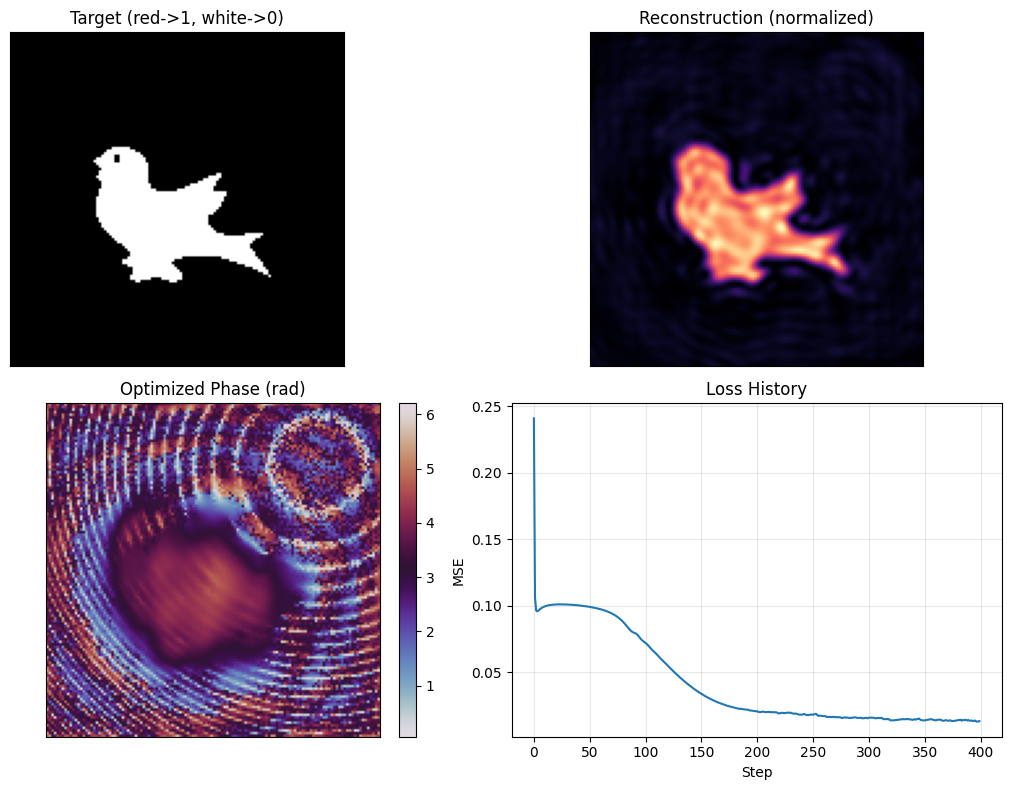

saved: artifacts/hologram_coherent_logo_overview.png


In [7]:
if PLOT:
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    axes[0, 0].imshow(np.asarray(target), cmap="gray", vmin=0.0, vmax=1.0)
    axes[0, 0].set_title("Target (red->1, white->0)")
    axes[0, 1].imshow(np.asarray(recon_norm), cmap="magma", vmin=0.0, vmax=1.0)
    axes[0, 1].set_title("Reconstruction (normalized)")
    phase_im = axes[1, 0].imshow(np.asarray(phase_opt), cmap="twilight")
    axes[1, 0].set_title("Optimized Phase (rad)")
    plt.colorbar(phase_im, ax=axes[1, 0], fraction=0.046, pad=0.04)
    axes[1, 1].plot(result.history)
    axes[1, 1].set_title("Loss History")
    axes[1, 1].set_xlabel("Step")
    axes[1, 1].set_ylabel("MSE")
    axes[1, 1].grid(alpha=0.3)
    for ax in (axes[0, 0], axes[0, 1], axes[1, 0]):
        ax.set_xticks([])
        ax.set_yticks([])
    fig.tight_layout()
    fig.savefig(PLOT_PATH, dpi=150)
    plt.show()
    print(f"saved: {PLOT_PATH}")
